# 🤖 06b — Entrenamiento v2 (features sin slope + threshold ajustado)
## Silver · Turbina Kelmarsh T1 · 2018–2021

---

### Qué cambia respecto a 06

| Aspecto | 06 original | 06b |
|---------|------------|-----|
| Features | Con `slope_*` (AUC=0.50) | Sin `slope_*`, con `p95`, `exceed`, `baseline_ratio` |
| Threshold | 0.50 (defecto) | **0.30** — prioriza Recall sobre Precision |
| `num_leaves` | 31 | **63** — más capacidad con mejor señal |
| `n_estimators` | 500 | **1000** + early stopping 100 |
| Archivos input | `features_{fam}.parquet` | `features_{fam}_v2.parquet` |
| Archivos output | `model_{fam}.pkl` | `model_{fam}_v2.pkl` |

### Por qué threshold 0.30 en lugar de 0.50

Con `class_weight='balanced'`, LightGBM ya compensa el desequilibrio internamente.  
Las probabilidades predichas para positivos suelen quedar en el rango 0.25–0.45 incluso con buen recall potencial.  
Con threshold 0.50, muchas alertas reales quedan por debajo del umbral → Recall artificialmente bajo.  
Con threshold 0.30 capturamos más fallos a costa de más falsas alarmas — aceptable en mantenimiento industrial.

El threshold óptimo se analiza en la sección de curva Precision-Recall de cada modelo.


## 0. Configuración Global

In [1]:
import os, json, pickle, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_curve, roc_auc_score)
warnings.filterwarnings('ignore')

base_dir  = os.path.dirname(os.getcwd())
silver_dir = os.path.join(base_dir, 'data', 'silver')
models_dir = os.path.join(base_dir, 'data', 'models')
os.makedirs(models_dir, exist_ok=True)

# ==============================================================================
# FAMILIAS
# ==============================================================================
FAULT_FAMILIES = {
    'yaw_cable':   {'lead_hours': 168, 'color': '#378ADD'},
    'generator':   {'lead_hours': 120, 'color': '#D85A30'},
    'brake_hydro': {'lead_hours': 120, 'color': '#BA7517'},
    'pitch_bat':   {'lead_hours': 336, 'color': '#1D9E75'},
}

# ==============================================================================
# HIPERPARÁMETROS v2
# Cambios vs v1:
#   - num_leaves: 31 → 63  (más capacidad, las features v2 tienen mejor señal)
#   - n_estimators: 500 → 1000 (early stopping para en el óptimo)
#   - early stopping: 50 → 100 (más paciencia, señal más débil tarda en converger)
# ==============================================================================
LGBM_PARAMS = {
    'n_estimators':     1000,
    'class_weight':     'balanced',
    'learning_rate':    0.05,
    'num_leaves':       63,
    'min_child_samples':20,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
}

# Threshold de clasificación — se aplica DESPUÉS del predict_proba
# 0.30 prioriza Recall (detectar fallos) sobre Precision (pocas falsas alarmas)
THRESHOLD = 0.30

TRAIN_RATIO = 0.80

print('Configuración v2 cargada')
print(f'  Threshold: {THRESHOLD} (vs 0.50 en v06 original)')
print(f'  num_leaves: {LGBM_PARAMS["num_leaves"]} (vs 31 en v06 original)')
print(f'  n_estimators: {LGBM_PARAMS["n_estimators"]} (con early stopping)')
print(f'  Archivos input: features_{{familia}}_v2.parquet')


Configuración v2 cargada
  Threshold: 0.3 (vs 0.50 en v06 original)
  num_leaves: 63 (vs 31 en v06 original)
  n_estimators: 1000 (con early stopping)
  Archivos input: features_{familia}_v2.parquet


---

## 1. Función de Entrenamiento y Evaluación v2

Cambios respecto al 06 original:
- Lee `features_{fam}_v2.parquet` en lugar de `features_{fam}.parquet`  
- Aplica `THRESHOLD` en lugar de `predict` directo
- Calcula la curva Precision-Recall y marca el threshold elegido
- Muestra el threshold óptimo para F1 por si quieres comparar


In [2]:
def train_family_v2(family, params=LGBM_PARAMS, train_ratio=TRAIN_RATIO, threshold=THRESHOLD, verbose=True):
    cfg = FAULT_FAMILIES[family]
    target_col = f'is_pre_{family}'
    hours_col  = f'hours_to_{family}'

    # ------------------------------------------------------------------
    # 1. CARGA — usar archivos v2
    # ------------------------------------------------------------------
    path = os.path.join(silver_dir, f'features_{family}_v2.parquet')
    if not os.path.exists(path):
        raise FileNotFoundError(f'No encontrado: {path}\nEjecuta primero 05b_feature_engineering.ipynb')
    
    df = pd.read_parquet(path)
    df = df.dropna(subset=[target_col])
    df = df.sort_values('timestamp').reset_index(drop=True)

    feature_cols = [c for c in df.columns if c not in ['timestamp', target_col, hours_col]]

    # ------------------------------------------------------------------
    # 2. SPLIT TEMPORAL 80/20
    # ------------------------------------------------------------------
    cutoff = df['timestamp'].quantile(train_ratio)
    train = df[df['timestamp'] <  cutoff].copy()
    test  = df[df['timestamp'] >= cutoff].copy()

    X_train = train[feature_cols].fillna(0)
    y_train = train[target_col].astype(int)
    X_test  = test[feature_cols].fillna(0)
    y_test  = test[target_col].astype(int)

    if verbose:
        print(f'\n{"="*60}')
        print(f'  FAMILIA: {family.upper()}  [v2]')
        print(f'{"="*60}')
        print(f'  Corte temporal:  {cutoff.date()}')
        print(f'  Train: {len(train):>7,} filas | {y_train.sum():>6,} positivos ({100*y_train.mean():.1f}%)')
        print(f'  Test:  {len(test):>7,} filas | {y_test.sum():>6,} positivos ({100*y_test.mean():.1f}%)')
        print(f'  Features: {len(feature_cols)}')
        print(f'  Threshold: {threshold}')

    # ------------------------------------------------------------------
    # 3. ENTRENAMIENTO
    # ------------------------------------------------------------------
    t0 = time.time()
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(200 if verbose else 0),
        ],
    )
    elapsed = time.time() - t0

    # ------------------------------------------------------------------
    # 4. PREDICCIÓN CON THRESHOLD AJUSTADO
    # ------------------------------------------------------------------
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)  # <-- threshold personalizado

    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=['Normal', 'Pre-fallo'],
                                   output_dict=True)

    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = float('nan')

    # Threshold óptimo para F1 (informativo)
    prec_curve, rec_curve, thresholds_curve = precision_recall_curve(y_test, y_prob)
    f1_curve = 2 * prec_curve * rec_curve / (prec_curve + rec_curve + 1e-9)
    best_thresh_idx = np.argmax(f1_curve[:-1])
    best_thresh_f1  = thresholds_curve[best_thresh_idx]
    best_f1         = f1_curve[best_thresh_idx]

    metrics = {
        'family':      family,
        'version':     'v2',
        'threshold':   threshold,
        'n_train':     int(len(train)),
        'n_test':      int(len(test)),
        'n_positives_train': int(y_train.sum()),
        'n_positives_test':  int(y_test.sum()),
        'precision':   round(report['Pre-fallo']['precision'], 4),
        'recall':      round(report['Pre-fallo']['recall'],    4),
        'f1':          round(report['Pre-fallo']['f1-score'],  4),
        'auc_roc':     round(auc, 4),
        'tn': int(cm[0,0]), 'fp': int(cm[0,1]),
        'fn': int(cm[1,0]), 'tp': int(cm[1,1]),
        'best_iteration': int(model.best_iteration_) if hasattr(model, 'best_iteration_') else params['n_estimators'],
        'best_threshold_for_f1': round(float(best_thresh_f1), 3),
        'best_f1_achievable':    round(float(best_f1), 4),
        'train_time_s': round(elapsed, 1),
    }

    if verbose:
        print(f'\n  RESULTADOS (threshold={threshold}):')
        print(f'    Precision:  {metrics["precision"]:.3f}  (objetivo > 0.50)')
        print(f'    Recall:     {metrics["recall"]:.3f}  (objetivo > 0.80) ← más importante')
        print(f'    F1:         {metrics["f1"]:.3f}  (objetivo > 0.60)')
        print(f'    AUC-ROC:    {metrics["auc_roc"]:.3f}')
        print(f'    Árboles usados: {metrics["best_iteration"]}')
        print(f'    Threshold óptimo para F1: {best_thresh_f1:.2f} → F1 máximo alcanzable: {best_f1:.3f}')
        print(f'\n  Matriz de confusión (threshold={threshold}):')
        print(f'    TN: {cm[0,0]:>7,}  FP: {cm[0,1]:>7,}')
        print(f'    FN: {cm[1,0]:>7,}  TP: {cm[1,1]:>7,}  ← FN son fallos no detectados')
        print(f'    Tiempo entrenamiento: {elapsed:.1f}s')

    return model, metrics, train, test, X_test, y_test, y_prob, feature_cols, (prec_curve, rec_curve, thresholds_curve)


print('Función train_family_v2 definida')


Función train_family_v2 definida


---

## 2. Funciones de Visualización

Se añade la **curva Precision-Recall** para elegir el threshold con criterio, además de los gráficos existentes.


In [3]:
def plot_feature_importance(model, feature_cols, family, top_n=20):
    cfg = FAULT_FAMILIES[family]
    feat_imp = pd.Series(model.feature_importances_, index=feature_cols)
    top = feat_imp.nlargest(top_n).sort_values()

    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
    bars = ax.barh(top.index, top.values, color=cfg['color'], alpha=0.8)
    ax.set_xlabel('Importancia (gain)')
    ax.set_title(f'Top {top_n} features — {family} [v2]\n¿Las más importantes tienen sentido físico?', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, top.values):
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=8)
    plt.tight_layout()
    path = os.path.join(models_dir, f'feature_importance_{family}_v2.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Guardado: feature_importance_{family}_v2.png')
    return top


def plot_pr_curve(pr_data, family, threshold):
    """Curva Precision-Recall con el threshold elegido marcado."""
    cfg = FAULT_FAMILIES[family]
    prec, rec, thresholds = pr_data

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(rec[:-1], prec[:-1], color=cfg['color'], linewidth=2, label='Curva P-R')

    # Marcar el threshold elegido
    idx_chosen = np.argmin(np.abs(thresholds - threshold))
    ax.scatter(rec[idx_chosen], prec[idx_chosen], color='red', s=100, zorder=5,
               label=f'Threshold={threshold:.2f}\nP={prec[idx_chosen]:.2f}, R={rec[idx_chosen]:.2f}')

    # Marcar el threshold óptimo para F1
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1_curve[:-1])
    ax.scatter(rec[best_idx], prec[best_idx], color='green', s=100, marker='*', zorder=5,
               label=f'Mejor F1 (th={thresholds[best_idx]:.2f})\nP={prec[best_idx]:.2f}, R={rec[best_idx]:.2f}')

    # Líneas de objetivo
    ax.axhline(0.50, color='gray', linestyle=':', alpha=0.5, label='Objetivo Precision=0.50')
    ax.axvline(0.80, color='orange', linestyle=':', alpha=0.5, label='Objetivo Recall=0.80')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Curva Precision-Recall — {family} [v2]\n'
                 f'Elige el threshold según la tolerancia a falsas alarmas', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    path = os.path.join(models_dir, f'pr_curve_{family}_v2.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Guardado: pr_curve_{family}_v2.png')


def plot_alert_timeline(test_df, y_prob, family, threshold):
    cfg = FAULT_FAMILIES[family]
    df_plot = test_df[['timestamp']].copy()
    df_plot['prob']     = y_prob
    df_plot['is_fault'] = test_df[f'is_pre_{family}'].values

    fault_moments = []
    prev = False
    for _, row in df_plot.iterrows():
        if prev and not row['is_fault']:
            fault_moments.append(row['timestamp'])
        prev = row['is_fault']

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.fill_between(df_plot['timestamp'], df_plot['prob'], alpha=0.35, color=cfg['color'], label='P(fallo próximo)')
    ax.plot(df_plot['timestamp'], df_plot['prob'], color=cfg['color'], linewidth=0.6, alpha=0.7)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2, label=f'Threshold {threshold}')
    ax.axhline(0.50, color='gray', linestyle=':', linewidth=0.8, alpha=0.6, label='Threshold original 0.50')

    for ft in fault_moments:
        ax.axvline(ft, color='darkred', alpha=0.8, linewidth=1.5, label='Fallo real')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left')

    ax.set_ylabel('Probabilidad de fallo')
    ax.set_ylim(0, 1)
    ax.set_title(f'Alertas predichas vs fallos reales — {family} [v2] (threshold={threshold})')
    ax.grid(alpha=0.2)
    plt.tight_layout()
    path = os.path.join(models_dir, f'timeline_{family}_v2.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Guardado: timeline_{family}_v2.png')


print('Funciones de visualización definidas')


Funciones de visualización definidas


---

## 3. Modelo 1 — `yaw_cable`

`cable_windings__baseline_ratio` debería ser la top feature — es la señal más directa de acumulación.


In [4]:
# ==============================================================================
# MODELO 1 — YAW_CABLE
# ==============================================================================
family = 'yaw_cable'

model_yawcable, metrics_yawcable, train_yawcable, test_yawcable, X_test_yawcable, y_test_yawcable, prob_yawcable, feats_yawcable, pr_yawcable = \
    train_family_v2(family)

pickle.dump(model_yawcable, open(os.path.join(models_dir, f'model_yaw_cable_v2.pkl'), 'wb'))
with open(os.path.join(models_dir, f'results_yaw_cable_v2.json'), 'w') as f:
    json.dump(metrics_yawcable, f, indent=2)
print('\nModelo y métricas guardados')



  FAMILIA: YAW_CABLE  [v2]
  Corte temporal:  2021-03-14
  Train: 168,307 filas | 76,776 positivos (45.6%)
  Test:   42,077 filas | 23,289 positivos (55.3%)
  Features: 204
  Threshold: 0.3

  RESULTADOS (threshold=0.3):
    Precision:  0.553  (objetivo > 0.50)
    Recall:     1.000  (objetivo > 0.80) ← más importante
    F1:         0.713  (objetivo > 0.60)
    AUC-ROC:    0.513
    Árboles usados: 2
    Threshold óptimo para F1: 0.45 → F1 máximo alcanzable: 0.716

  Matriz de confusión (threshold=0.3):
    TN:       0  FP:  18,788
    FN:       0  TP:  23,289  ← FN son fallos no detectados
    Tiempo entrenamiento: 6.7s

Modelo y métricas guardados


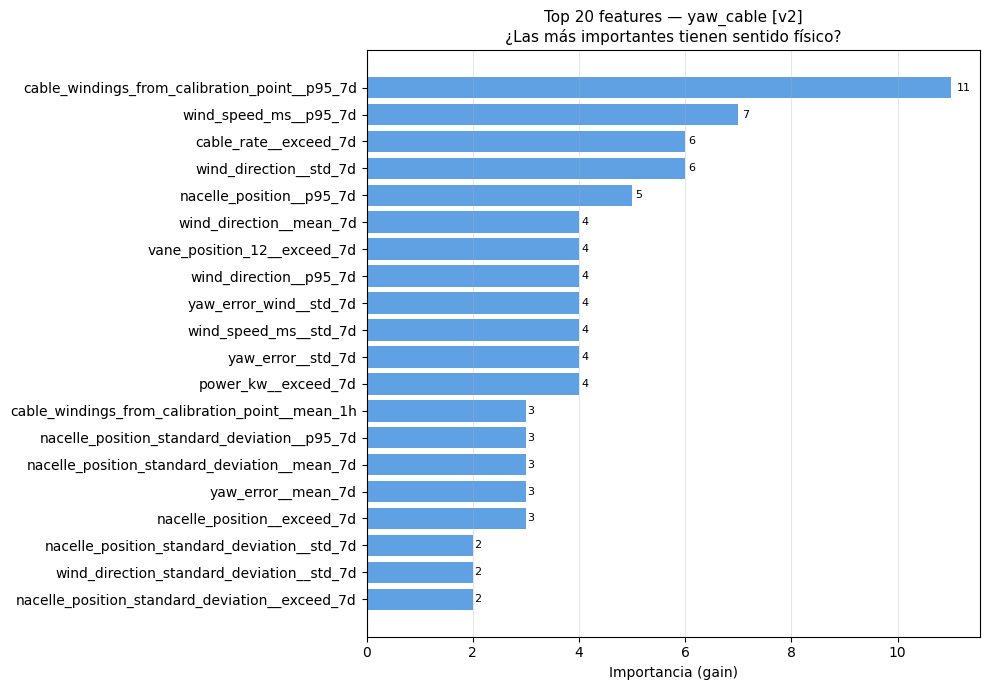

  Guardado: feature_importance_yaw_cable_v2.png


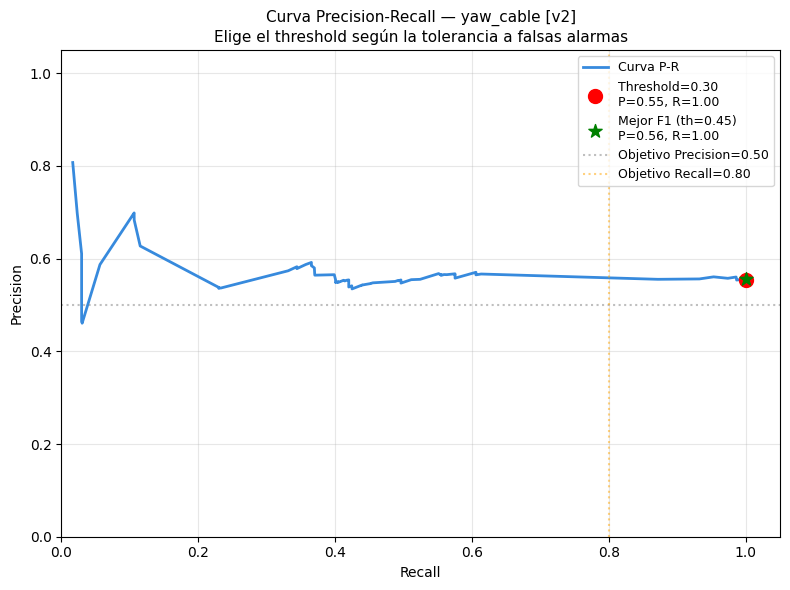

  Guardado: pr_curve_yaw_cable_v2.png


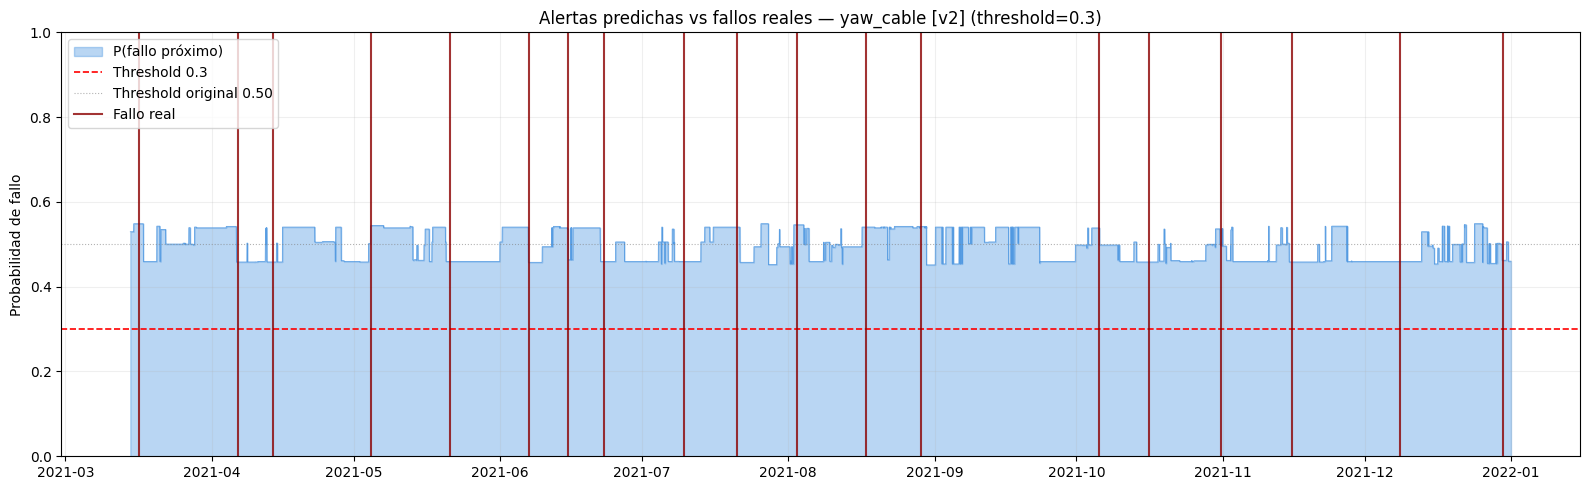

  Guardado: timeline_yaw_cable_v2.png


In [5]:
top_feats_yawcable = plot_feature_importance(model_yawcable, feats_yawcable, family)
plot_pr_curve(pr_yawcable, family, THRESHOLD)
plot_alert_timeline(test_yawcable, prob_yawcable, family, THRESHOLD)


---

## 4. Modelo 2 — `generator`

`t_bearing_delta__p95_7d` debería superar a `t_bearing_delta__mean_7d` — los picos de temperatura son la señal.


In [6]:
# ==============================================================================
# MODELO 2 — GENERATOR
# ==============================================================================
family = 'generator'

model_generator, metrics_generator, train_generator, test_generator, X_test_generator, y_test_generator, prob_generator, feats_generator, pr_generator = \
    train_family_v2(family)

pickle.dump(model_generator, open(os.path.join(models_dir, f'model_generator_v2.pkl'), 'wb'))
with open(os.path.join(models_dir, f'results_generator_v2.json'), 'w') as f:
    json.dump(metrics_generator, f, indent=2)
print('\nModelo y métricas guardados')



  FAMILIA: GENERATOR  [v2]
  Corte temporal:  2021-03-14
  Train: 168,307 filas | 19,384 positivos (11.5%)
  Test:   42,077 filas |  2,888 positivos (6.9%)
  Features: 357
  Threshold: 0.3

  RESULTADOS (threshold=0.3):
    Precision:  0.075  (objetivo > 0.50)
    Recall:     0.250  (objetivo > 0.80) ← más importante
    F1:         0.116  (objetivo > 0.60)
    AUC-ROC:    0.642
    Árboles usados: 56
    Threshold óptimo para F1: 0.13 → F1 máximo alcanzable: 0.198

  Matriz de confusión (threshold=0.3):
    TN:  30,313  FP:   8,876
    FN:   2,165  TP:     723  ← FN son fallos no detectados
    Tiempo entrenamiento: 11.5s

Modelo y métricas guardados


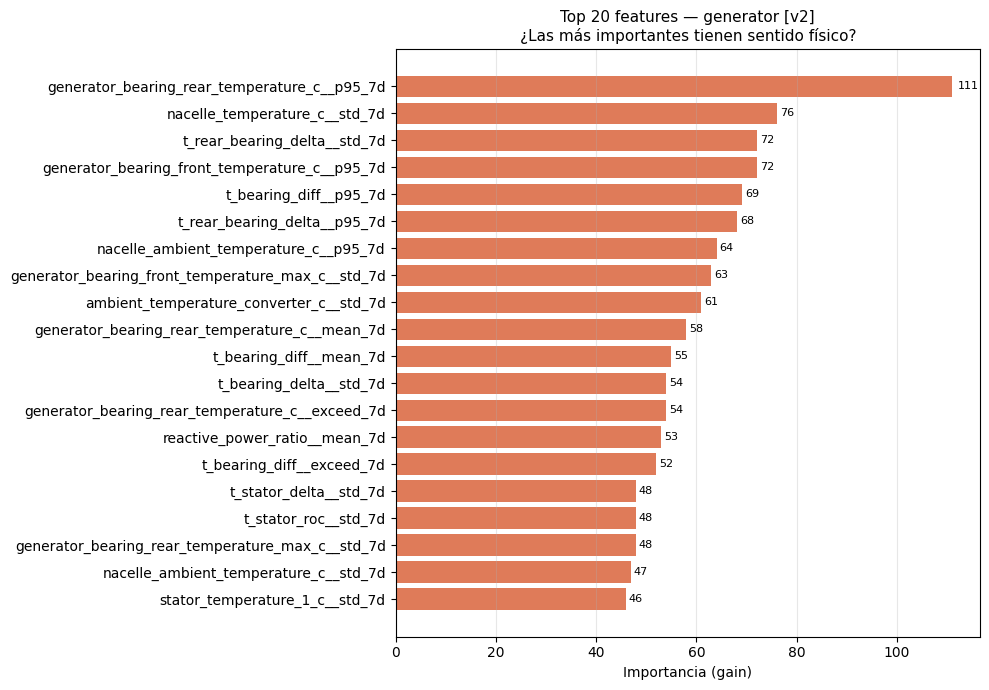

  Guardado: feature_importance_generator_v2.png


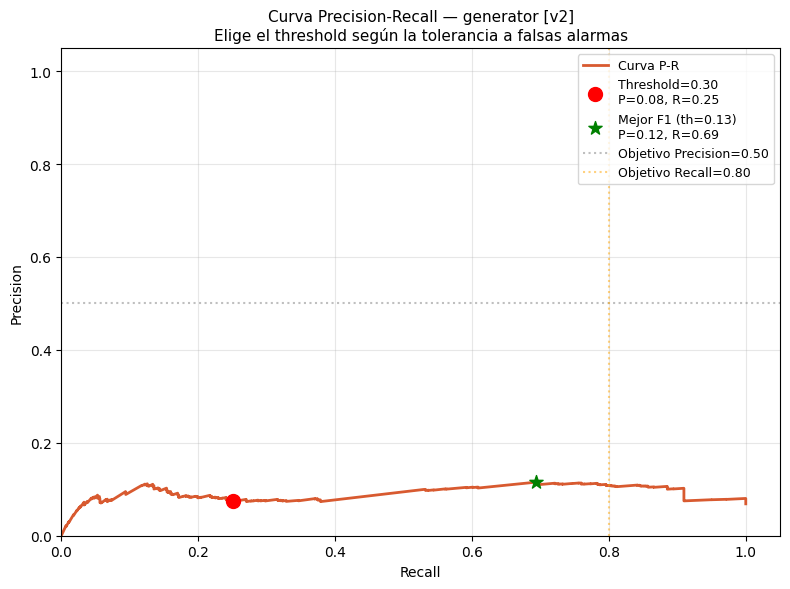

  Guardado: pr_curve_generator_v2.png


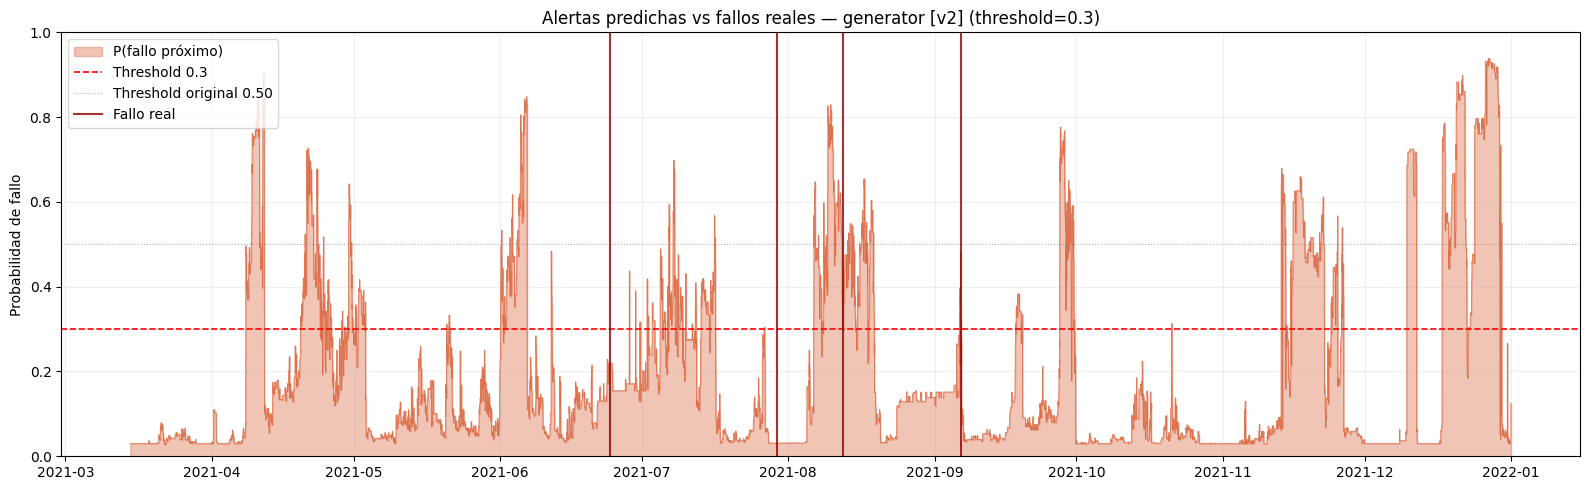

  Guardado: timeline_generator_v2.png


In [7]:
top_feats_generator = plot_feature_importance(model_generator, feats_generator, family)
plot_pr_curve(pr_generator, family, THRESHOLD)
plot_alert_timeline(test_generator, prob_generator, family, THRESHOLD)


---

## 5. Modelo 3 (más regularizado) — `brake_hydro`

Con solo 58 eventos, mantenemos más regularización. Si Recall < 0.50, intentar threshold=0.20.


In [8]:
# ==============================================================================
# MODELO 3 — BRAKE_HYDRO
# ==============================================================================
family = 'brake_hydro'

params_hydro = {**LGBM_PARAMS, 'num_leaves': 31, 'min_child_samples': 30}

model_brakehydro, metrics_brakehydro, train_brakehydro, test_brakehydro, X_test_brakehydro, y_test_brakehydro, prob_brakehydro, feats_brakehydro, pr_brakehydro = \
    train_family_v2(family, params=params_hydro)

pickle.dump(model_brakehydro, open(os.path.join(models_dir, f'model_brake_hydro_v2.pkl'), 'wb'))
with open(os.path.join(models_dir, f'results_brake_hydro_v2.json'), 'w') as f:
    json.dump(metrics_brakehydro, f, indent=2)
print('\nModelo y métricas guardados')



  FAMILIA: BRAKE_HYDRO  [v2]
  Corte temporal:  2021-03-14
  Train: 168,307 filas | 18,334 positivos (10.9%)
  Test:   42,077 filas |  2,851 positivos (6.8%)
  Features: 238
  Threshold: 0.3

  RESULTADOS (threshold=0.3):
    Precision:  0.092  (objetivo > 0.50)
    Recall:     0.146  (objetivo > 0.80) ← más importante
    F1:         0.113  (objetivo > 0.60)
    AUC-ROC:    0.478
    Árboles usados: 55
    Threshold óptimo para F1: 0.27 → F1 máximo alcanzable: 0.139

  Matriz de confusión (threshold=0.3):
    TN:  35,145  FP:   4,081
    FN:   2,436  TP:     415  ← FN son fallos no detectados
    Tiempo entrenamiento: 5.5s

Modelo y métricas guardados


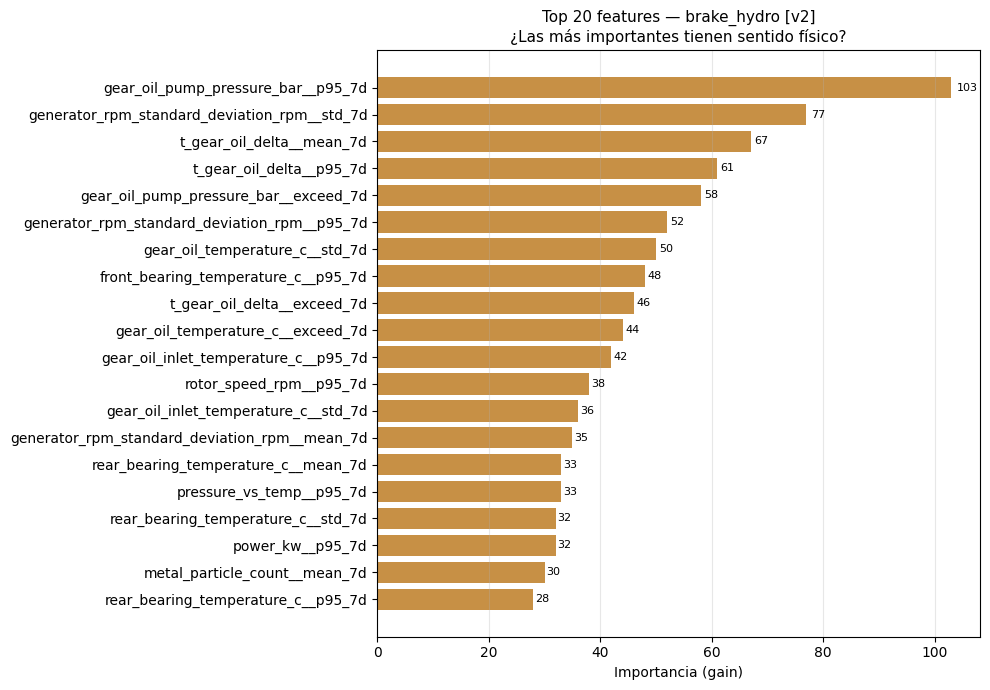

  Guardado: feature_importance_brake_hydro_v2.png


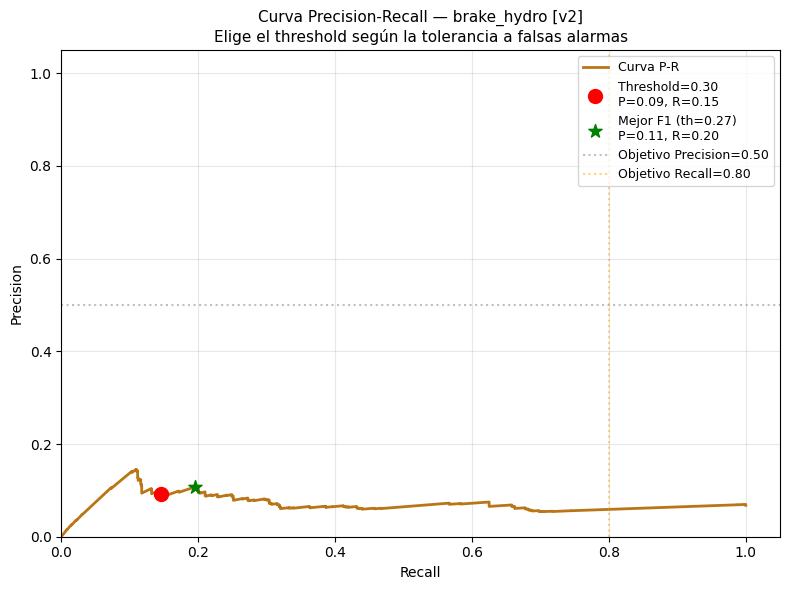

  Guardado: pr_curve_brake_hydro_v2.png


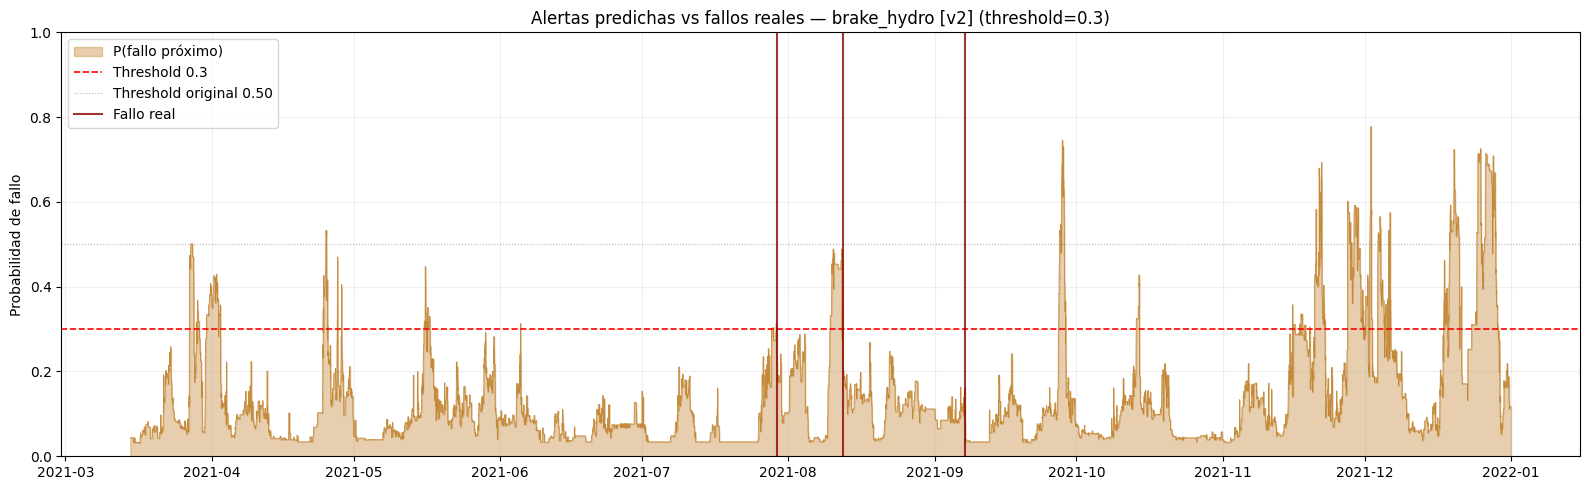

  Guardado: timeline_brake_hydro_v2.png


In [9]:
top_feats_brakehydro = plot_feature_importance(model_brakehydro, feats_brakehydro, family)
plot_pr_curve(pr_brakehydro, family, THRESHOLD)
plot_alert_timeline(test_brakehydro, prob_brakehydro, family, THRESHOLD)


---

## 6. Modelo 4 — `pitch_bat`

`temperature_motor_*__exceed_7d` debería aparecer — las baterías fallan cuando el frío es sostenido.


In [10]:
# ==============================================================================
# MODELO 4 — PITCH_BAT
# ==============================================================================
family = 'pitch_bat'

model_pitchbat, metrics_pitchbat, train_pitchbat, test_pitchbat, X_test_pitchbat, y_test_pitchbat, prob_pitchbat, feats_pitchbat, pr_pitchbat = \
    train_family_v2(family)

pickle.dump(model_pitchbat, open(os.path.join(models_dir, f'model_pitch_bat_v2.pkl'), 'wb'))
with open(os.path.join(models_dir, f'results_pitch_bat_v2.json'), 'w') as f:
    json.dump(metrics_pitchbat, f, indent=2)
print('\nModelo y métricas guardados')



  FAMILIA: PITCH_BAT  [v2]
  Corte temporal:  2021-03-14
  Train: 168,307 filas | 24,727 positivos (14.7%)
  Test:   42,077 filas |  4,026 positivos (9.6%)
  Features: 255
  Threshold: 0.3

  RESULTADOS (threshold=0.3):
    Precision:  0.123  (objetivo > 0.50)
    Recall:     0.330  (objetivo > 0.80) ← más importante
    F1:         0.179  (objetivo > 0.60)
    AUC-ROC:    0.542
    Árboles usados: 41
    Threshold óptimo para F1: 0.60 → F1 máximo alcanzable: 0.238

  Matriz de confusión (threshold=0.3):
    TN:  28,563  FP:   9,488
    FN:   2,697  TP:   1,329  ← FN son fallos no detectados
    Tiempo entrenamiento: 7.9s

Modelo y métricas guardados


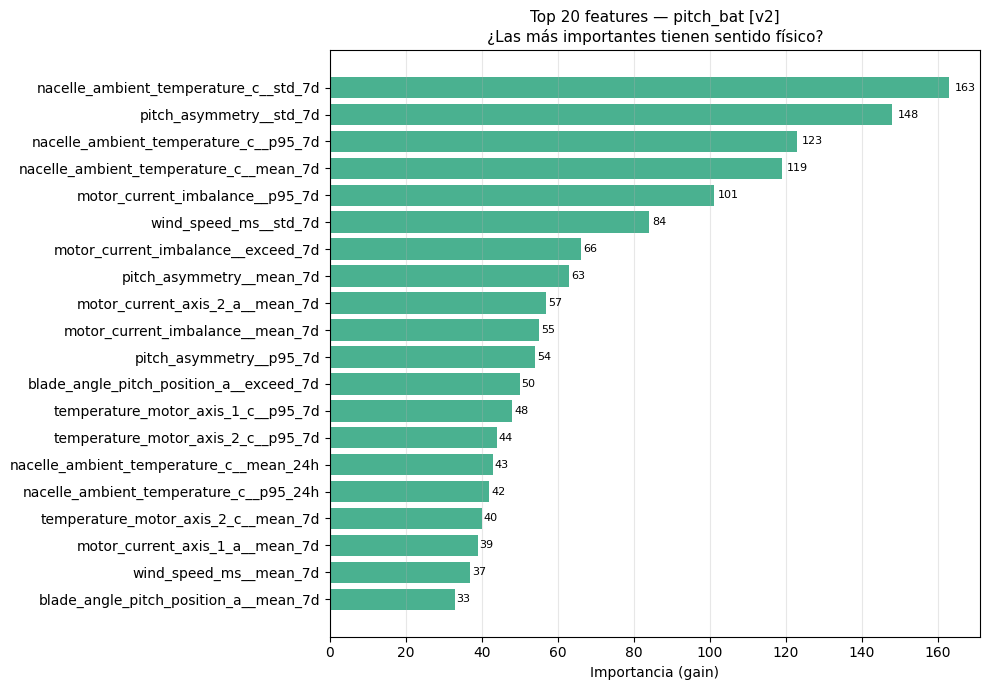

  Guardado: feature_importance_pitch_bat_v2.png


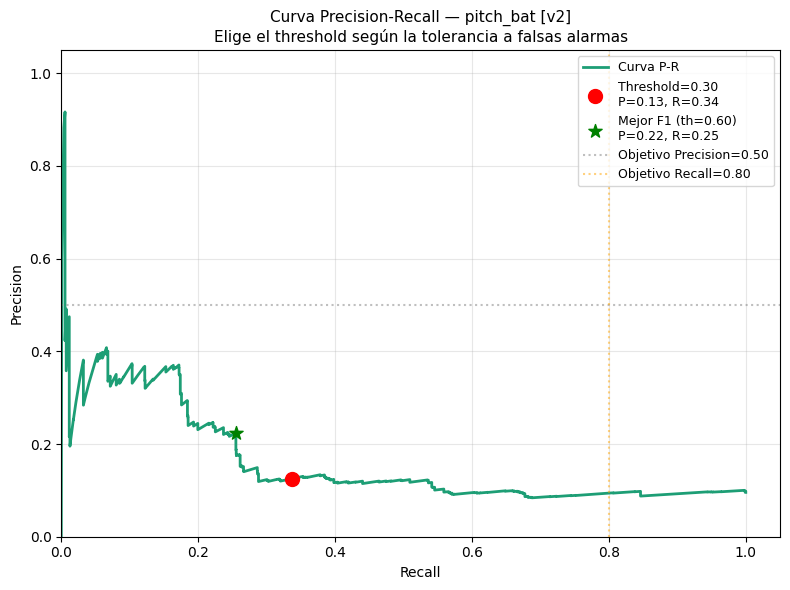

  Guardado: pr_curve_pitch_bat_v2.png


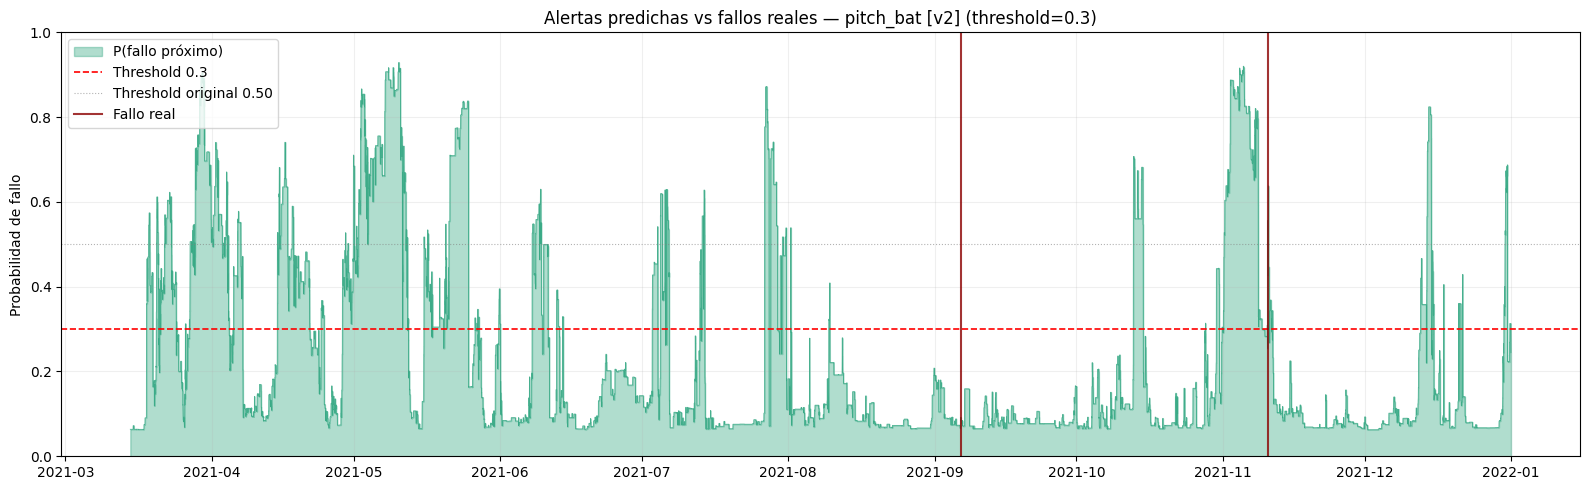

  Guardado: timeline_pitch_bat_v2.png


In [11]:
top_feats_pitchbat = plot_feature_importance(model_pitchbat, feats_pitchbat, family)
plot_pr_curve(pr_pitchbat, family, THRESHOLD)
plot_alert_timeline(test_pitchbat, prob_pitchbat, family, THRESHOLD)


---

## 7. Resumen Comparativo v2 vs v1


In [12]:
# ==============================================================================
# RESUMEN v2
# ==============================================================================
all_metrics_v2 = [metrics_yawcable, metrics_generator, metrics_brakehydro, metrics_pitchbat]

df_v2 = pd.DataFrame([{
    'Familia':   m['family'],
    'Threshold': m['threshold'],
    'Precision': m['precision'],
    'Recall':    m['recall'],
    'F1':        m['f1'],
    'AUC-ROC':   m['auc_roc'],
    'Best thresh (F1)': m['best_threshold_for_f1'],
    'Max F1 posible':   m['best_f1_achievable'],
    'FN': m['fn'],
    'FP': m['fp'],
} for m in all_metrics_v2])

print('\n' + '='*80)
print('RESUMEN — 4 MODELOS v2')
print('='*80)
print(df_v2.to_string(index=False))

print('\nOBJETIVOS:')
print('  Recall    > 0.80  ← prioridad máxima')
print('  Precision > 0.50')
print('  F1        > 0.60')

# Comparativa vs v1
print('\n' + '='*80)
print('COMPARATIVA v1 vs v2 (Recall)')
print('='*80)
v1_recall = {'yaw_cable': 0.4068, 'generator': 0.0322, 'brake_hydro': 0.0989, 'pitch_bat': 0.2586}
v1_auc    = {'yaw_cable': 0.5608, 'generator': 0.5314, 'brake_hydro': 0.4339, 'pitch_bat': 0.4815}

print(f'{"Familia":<15} {"Recall v1":>10} {"Recall v2":>10} {"Delta":>8} {"AUC v1":>10} {"AUC v2":>10}')
print('-' * 65)
for _, row in df_v2.iterrows():
    fam = row['Familia']
    r1 = v1_recall.get(fam, 0)
    r2 = row['Recall']
    a1 = v1_auc.get(fam, 0)
    a2 = row['AUC-ROC']
    delta = r2 - r1
    flag = '✅' if r2 >= 0.80 else ('⚠️' if r2 >= 0.50 else '❌')
    print(f'{fam:<15} {r1:>10.3f} {r2:>10.3f} {delta:>+8.3f} {a1:>10.3f} {a2:>10.3f}  {flag}')

for _, row in df_v2.iterrows():
    issues = []
    if row['Recall'] < 0.80:    issues.append(f'Recall bajo ({row["Recall"]:.2f})')
    if row['Precision'] < 0.50: issues.append(f'Precision baja ({row["Precision"]:.2f})')
    if issues:
        bth = row['Best thresh (F1)']
        print(f'\n  ⚠️  {row["Familia"]}: {", ".join(issues)}')
        print(f'       → Prueba threshold={bth:.2f} (óptimo para F1) o aumenta lead time')
    else:
        print(f'  ✅  {row["Familia"]}: todos los objetivos cumplidos')



RESUMEN — 4 MODELOS v2
    Familia  Threshold  Precision  Recall     F1  AUC-ROC  Best thresh (F1)  Max F1 posible   FN    FP
  yaw_cable        0.3     0.5535  1.0000 0.7126   0.5132             0.452          0.7155    0 18788
  generator        0.3     0.0753  0.2503 0.1158   0.6422             0.130          0.1978 2165  8876
brake_hydro        0.3     0.0923  0.1456 0.1130   0.4778             0.274          0.1389 2436  4081
  pitch_bat        0.3     0.1229  0.3301 0.1791   0.5425             0.604          0.2377 2697  9488

OBJETIVOS:
  Recall    > 0.80  ← prioridad máxima
  Precision > 0.50
  F1        > 0.60

COMPARATIVA v1 vs v2 (Recall)
Familia          Recall v1  Recall v2    Delta     AUC v1     AUC v2
-----------------------------------------------------------------
yaw_cable            0.407      1.000   +0.593      0.561      0.513  ✅
generator            0.032      0.250   +0.218      0.531      0.642  ❌
brake_hydro          0.099      0.146   +0.047      0.434     

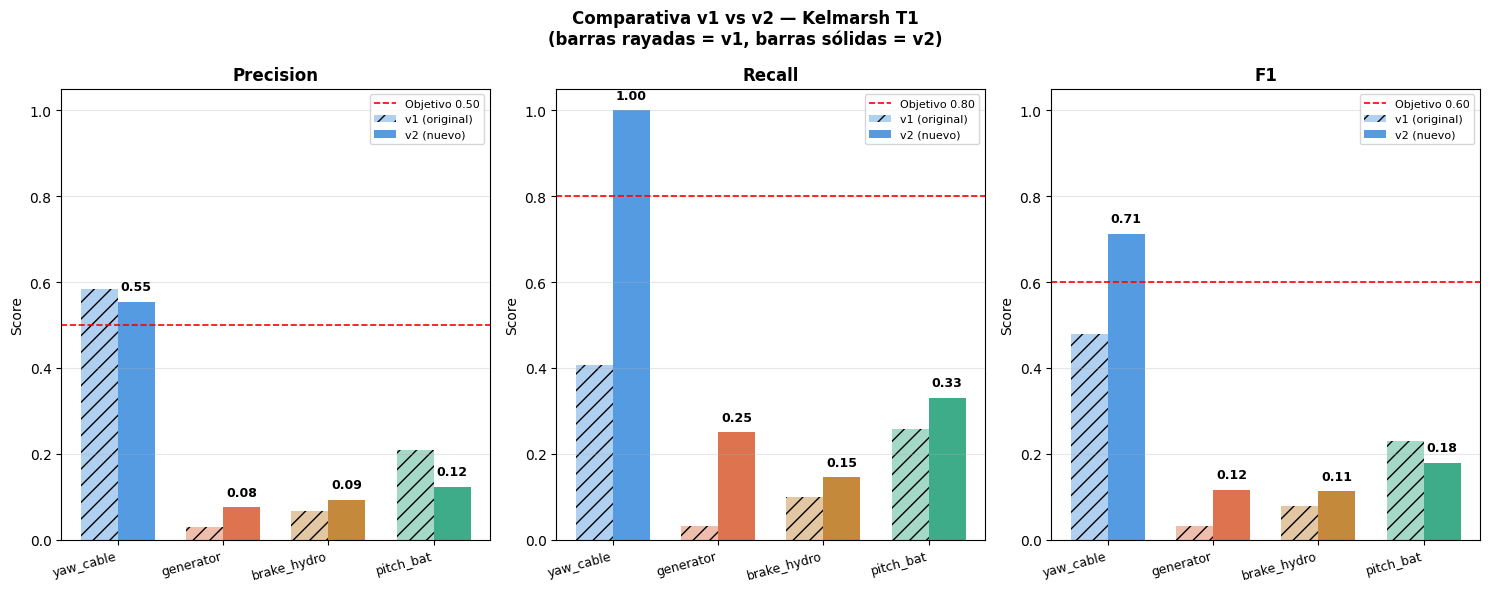

Guardado: results_comparison_v1_v2.png


In [13]:
# Gráfico comparativo v1 vs v2
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
metrics_plot = ['Precision', 'Recall', 'F1']
objectives   = [0.50, 0.80, 0.60]
colors_bars  = [FAULT_FAMILIES[f]['color'] for f in df_v2['Familia']]

v1_vals = {
    'Precision': [0.5841, 0.0303, 0.0662, 0.2086],
    'Recall':    [0.4068, 0.0322, 0.0989, 0.2586],
    'F1':        [0.4796, 0.0312, 0.0793, 0.2309],
}

x = np.arange(len(df_v2))
width = 0.35

for ax, metric, obj in zip(axes, metrics_plot, objectives):
    bars1 = ax.bar(x - width/2, v1_vals[metric], width, label='v1 (original)',
                   color=colors_bars, alpha=0.40, hatch='//')
    bars2 = ax.bar(x + width/2, df_v2[metric].values, width, label='v2 (nuevo)',
                   color=colors_bars, alpha=0.85)
    ax.axhline(obj, color='red', linestyle='--', linewidth=1.2, label=f'Objetivo {obj:.2f}')
    ax.set_ylim(0, 1.05)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(df_v2['Familia'], rotation=15, ha='right', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars2, df_v2[metric].values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Comparativa v1 vs v2 — Kelmarsh T1\n(barras rayadas = v1, barras sólidas = v2)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
path = os.path.join(models_dir, 'results_comparison_v1_v2.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: results_comparison_v1_v2.png')


---

## 📋 Resumen y Siguientes Pasos

### Si los resultados siguen siendo malos (Recall < 0.50)

1. **Mira la columna `Best thresh (F1)`** del resumen — si es muy diferente de 0.30, prueba ese threshold
2. **Mira el AUC-ROC** — si sigue ~0.50, el problema es la señal, no el threshold:
   - Revisar el etiquetado (¿los lead times son correctos?)
   - Añadir más sensores externos (temperatura exterior, historial de mantenimiento)
   - Considerar un modelo de anomalía (no supervisado) como complemento
3. **Mira el gráfico de timeline** — si la probabilidad predicha nunca supera 0.30, la señal sigue siendo muy débil

### Si los resultados son buenos (Recall > 0.80)

El siguiente paso es **07_threshold_tuning.ipynb** — ajuste fino del threshold por familia  
según el coste operativo real de cada tipo de falso positivo/negativo.
